# Pull GEDI L1B and L2A footprints within the RCEW raster bounding box

This notebook uses the RCEW 10 m template raster to define the CMR search bounding box, pulls GEDI L1B (`GEDI01_B`) and GEDI L2A (`GEDI02_A`) granules, extracts footprint-level records file-by-file, and clips them immediately to the RCEW AOI shapefile.

Default input raster:

```text
A:\RCEW_DATA\template_grid\RCEW_template_grid_26911_10m.tif
```

Core AOI shapefile:

```text
A:\RCEW_DATA\Templates\RCEW_shapefile\RCEW_extent_26911.shp
```

Output root:

```text
A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template_bbox_L1B_L2A
```

Important: the L1B product contains geolocated waveform data. This notebook does **not** flatten full waveform arrays into the main footprint table. It stores per-shot waveform pointer fields so waveforms can be retrieved lazily from the retained raw HDF5 files later.


## 0. Install dependencies if needed

Run this cell once in the conda environment if any imports fail.


In [ ]:
# Uncomment if needed
# %pip install earthaccess rasterio geopandas shapely pyproj h5py pandas numpy tqdm pyogrio


## 1. Imports and configuration


In [1]:
from pathlib import Path
import os
import re
import warnings

import earthaccess
import h5py
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.warp import transform_bounds
from rasterio.transform import rowcol
from shapely.geometry import box
from tqdm.std import tqdm

warnings.filterwarnings("ignore", category=UserWarning)

# -------------------------
# User settings
# -------------------------
RASTER_PATH = Path(r"A:\RCEW_DATA\template_grid\RCEW_template_grid_26911_10m.tif")

# GEDI products requested
GEDI_PRODUCTS = {
    "L1B": "GEDI01_B",   # Level 1B geolocated waveform data
    "L2A": "GEDI02_A",   # Level 2A elevation and RH height metrics
}
GEDI_VERSION = "002"

# GEDI V002 public archive. Narrow this if you only need a specific season/year.
TEMPORAL_RANGE = ("2019-04-18", "2024-11-29")

# Increase if your AOI/date range returns many granules.
MAX_GRANULES_PER_PRODUCT = 500

# True = download HDF5 files locally; False = stream/open with earthaccess.
# For repeated development, downloading is usually more stable.
DOWNLOAD_GRANULES = True

OUT_DIR = Path(r"A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template_bbox_L1B_L2A")
OUT_DIR.mkdir(parents=True, exist_ok=True)
RAW_DIR = OUT_DIR / "raw_h5"
RAW_DIR.mkdir(parents=True, exist_ok=True)

OUT_GPKG = OUT_DIR / "RCEW_GEDI_L1B_L2A_footprints_core_aoi.gpkg"
OUT_L1B_CSV = OUT_DIR / "RCEW_GEDI01_B_L1B_footprints_core_aoi.csv"
OUT_L2A_CSV = OUT_DIR / "RCEW_GEDI02_A_L2A_footprints_core_aoi.csv"
OUT_JOINED_CSV = OUT_DIR / "RCEW_GEDI01_B_GEDI02_A_joined_core_aoi.csv"

print("Output directory:", OUT_DIR)


Output directory: A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template_bbox_L1B_L2A


## 2. Read raster bounds and transform to WGS84

The GEDI/CMR search needs longitude/latitude coordinates. The raster can stay in its native CRS for exact spatial filtering and grid row/column indexing.


In [2]:
if not RASTER_PATH.exists():
    raise FileNotFoundError(f"Raster not found: {RASTER_PATH}")

with rasterio.open(RASTER_PATH) as src:
    raster_crs = src.crs
    raster_bounds = src.bounds
    raster_transform = src.transform
    raster_width = src.width
    raster_height = src.height
    raster_res = src.res

print("Raster CRS:", raster_crs)
print("Raster bounds in raster CRS:", raster_bounds)
print("Raster size:", raster_width, "x", raster_height)
print("Raster resolution:", raster_res)

west, south, east, north = transform_bounds(
    raster_crs,
    "EPSG:4326",
    raster_bounds.left,
    raster_bounds.bottom,
    raster_bounds.right,
    raster_bounds.top,
    densify_pts=21,
)

cmr_bbox = (west, south, east, north)
print("CMR/WGS84 bounding box:", cmr_bbox)

raster_bbox_poly = box(raster_bounds.left, raster_bounds.bottom, raster_bounds.right, raster_bounds.top)
aoi_native = gpd.GeoDataFrame({"name": ["raster_bbox"]}, geometry=[raster_bbox_poly], crs=raster_crs)
aoi_wgs84 = aoi_native.to_crs("EPSG:4326")


Raster CRS: EPSG:26911
Raster bounds in raster CRS: BoundingBox(left=511400.0, bottom=4767590.0, right=525330.0, top=4795590.0)
Raster size: 1393 x 2800
Raster resolution: (10.0, 10.0)
CMR/WGS84 bounding box: (-116.85999925013725, 43.06058806698786, -116.68764663478046, 43.31305873460629)


## 3. Authenticate with NASA Earthdata


In [3]:
# This uses an existing .netrc if present, or prompts for NASA Earthdata credentials.
auth = earthaccess.login(persist=True)
auth


## 4. Search and prepare L1B and L2A granules

CMR returns candidate granules that intersect the raster-derived WGS84 bbox. Exact footprint clipping happens after reading each HDF5 file.


In [4]:
def get_granule_name(granule):
    """
    Extract a readable granule name from an earthaccess DataGranule object.

    Different earthaccess versions expose metadata differently, so this avoids
    using granule.summary(), which is not available in your installed version.
    """
    try:
        return granule["umm"].get("GranuleUR", "unknown granule")
    except Exception:
        pass

    try:
        return granule.get("umm", {}).get("GranuleUR", "unknown granule")
    except Exception:
        pass

    try:
        return granule.get("meta", {}).get("native-id", "unknown granule")
    except Exception:
        pass

    return "unknown granule"


def search_gedi_product(short_name, label):
    results = earthaccess.search_data(
        short_name=short_name,
        version=GEDI_VERSION,
        bounding_box=cmr_bbox,
        temporal=TEMPORAL_RANGE,
        count=MAX_GRANULES_PER_PRODUCT,
    )

    print(f"{label} / {short_name}: found {len(results)} candidate granules")

    if results:
        print("Example granules:")
        for i, granule in enumerate(results[:3]):
            print(f"  [{i}] {get_granule_name(granule)}")

    return results


results_by_level = {
    level: search_gedi_product(short_name, level)
    for level, short_name in GEDI_PRODUCTS.items()
}

if not results_by_level["L1B"]:
    raise RuntimeError(
        "No GEDI L1B granules found. Check bbox, dates, product version, or MAX_GRANULES_PER_PRODUCT."
    )

if not results_by_level["L2A"]:
    raise RuntimeError(
        "No GEDI L2A granules found. Check bbox, dates, product version, or MAX_GRANULES_PER_PRODUCT."
    )

c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\earthaccess\results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


L1B / GEDI01_B: found 85 candidate granules
Example granules:
  [0] GEDI01_B_2019137101716_O02416_03_T03984_02_005_01_V002
  [1] GEDI01_B_2019142030259_O02489_02_T00140_02_005_01_V002
  [2] GEDI01_B_2019144073502_O02523_03_T02408_02_005_01_V002
L2A / GEDI02_A: found 85 candidate granules
Example granules:
  [0] GEDI02_A_2019137101716_O02416_03_T03984_02_003_01_V002
  [1] GEDI02_A_2019142030259_O02489_02_T00140_02_003_01_V002
  [2] GEDI02_A_2019144073502_O02523_03_T02408_02_003_01_V002


In [5]:
def gedi_pair_key(granule_name):
    """
    Extract stable orbit/time/track key from GEDI granule name.

    Example:
    GEDI01_B_2019109210809_O01988_03_T02056_02_005_01_V002
    -> 2019109210809_O01988_03_T02056_02
    """
    parts = granule_name.split("_")

    # parts:
    # [0] GEDI01
    # [1] B or A
    # [2] timestamp
    # [3] orbit
    # [4] sub-orbit/beam group
    # [5] track
    # [6] processing segment
    return "_".join(parts[2:7])


granule_tables = {}

for level, granules in results_by_level.items():
    rows = []
    for g in granules:
        name = get_granule_name(g)
        rows.append(
            {
                "level": level,
                "granule_name": name,
                "pair_key": gedi_pair_key(name),
            }
        )
    granule_tables[level] = pd.DataFrame(rows)

l1b_keys = set(granule_tables["L1B"]["pair_key"])
l2a_keys = set(granule_tables["L2A"]["pair_key"])

print("L1B granules:", len(l1b_keys))
print("L2A granules:", len(l2a_keys))
print("Matched granule keys:", len(l1b_keys & l2a_keys))
print("L1B only:", len(l1b_keys - l2a_keys))
print("L2A only:", len(l2a_keys - l1b_keys))

display(granule_tables["L1B"].head())
display(granule_tables["L2A"].head())

L1B granules: 85
L2A granules: 85
Matched granule keys: 85
L1B only: 0
L2A only: 0


,level,granule_name,pair_key
0,L1B,GEDI01_B_2019137101716_O02416_03_T03984_02_005...,2019137101716_O02416_03_T03984_02
1,L1B,GEDI01_B_2019142030259_O02489_02_T00140_02_005...,2019142030259_O02489_02_T00140_02
2,L1B,GEDI01_B_2019144073502_O02523_03_T02408_02_005...,2019144073502_O02523_03_T02408_02
3,L1B,GEDI01_B_2019152224635_O02657_02_T05679_02_005...,2019152224635_O02657_02_T05679_02
4,L1B,GEDI01_B_2019169212519_O02920_03_T05407_02_005...,2019169212519_O02920_03_T05407_02


,level,granule_name,pair_key
0,L2A,GEDI02_A_2019137101716_O02416_03_T03984_02_003...,2019137101716_O02416_03_T03984_02
1,L2A,GEDI02_A_2019142030259_O02489_02_T00140_02_003...,2019142030259_O02489_02_T00140_02
2,L2A,GEDI02_A_2019144073502_O02523_03_T02408_02_003...,2019144073502_O02523_03_T02408_02
3,L2A,GEDI02_A_2019152224635_O02657_02_T05679_02_003...,2019152224635_O02657_02_T05679_02
4,L2A,GEDI02_A_2019169212519_O02920_03_T05407_02_003...,2019169212519_O02920_03_T05407_02


## 5. Download or open HDF5 sources


In [6]:
def prepare_h5_sources(results, short_name):
    product_raw_dir = RAW_DIR / short_name
    product_raw_dir.mkdir(parents=True, exist_ok=True)
    if DOWNLOAD_GRANULES:
        paths = earthaccess.download(results, local_path=str(product_raw_dir))
        return [Path(p) for p in paths]
    return earthaccess.open(results)

h5_sources_by_level = {}
for level, short_name in GEDI_PRODUCTS.items():
    h5_sources_by_level[level] = prepare_h5_sources(results_by_level[level], short_name)
    print(f"{level}: prepared {len(h5_sources_by_level[level])} HDF5 sources")

h5_sources_by_level["L1B"][:2], h5_sources_by_level["L2A"][:2]


c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\earthaccess\store.py:838: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum(granule.size() for granule in granules) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/85 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/85 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/85 [00:00<?, ?it/s]

L1B: prepared 85 HDF5 sources


QUEUEING TASKS | :   0%|          | 0/85 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/85 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/85 [00:00<?, ?it/s]

L2A: prepared 85 HDF5 sources


([WindowsPath('A:/RCEW_DATA/Ancillary_Data/GEDI/RCEW_template_bbox_L1B_L2A/raw_h5/GEDI01_B/GEDI01_B_2019137101716_O02416_03_T03984_02_005_01_V002.h5'),
  WindowsPath('A:/RCEW_DATA/Ancillary_Data/GEDI/RCEW_template_bbox_L1B_L2A/raw_h5/GEDI01_B/GEDI01_B_2019142030259_O02489_02_T00140_02_005_01_V002.h5')],
 [WindowsPath('A:/RCEW_DATA/Ancillary_Data/GEDI/RCEW_template_bbox_L1B_L2A/raw_h5/GEDI02_A/GEDI02_A_2019137101716_O02416_03_T03984_02_003_01_V002.h5'),
  WindowsPath('A:/RCEW_DATA/Ancillary_Data/GEDI/RCEW_template_bbox_L1B_L2A/raw_h5/GEDI02_A/GEDI02_A_2019142030259_O02489_02_T00140_02_003_01_V002.h5')])

## 6. HDF5 extraction helpers

These helpers tolerate the main coordinate-path differences between L1B and L2A. They extract a compact footprint table and avoid expanding the full L1B waveform arrays unless requested later.


In [7]:
BEAM_RE = re.compile(r"^BEAM\d{4}$")


def list_beams(h5):
    return sorted([k for k in h5.keys() if BEAM_RE.match(k)])


def dataset_exists(group, path):
    try:
        obj = group[path]
        return isinstance(obj, h5py.Dataset)
    except Exception:
        return False


def read_first_dataset(group, candidate_paths):
    for path in candidate_paths:
        if dataset_exists(group, path):
            return np.asarray(group[path]), path
    return None, None


def to_1d(arr, n=None):
    if arr is None:
        return None
    arr = np.asarray(arr)
    if arr.ndim == 0:
        return None
    if arr.ndim > 1:
        return None
    if n is not None and len(arr) != n:
        return None
    if arr.dtype.kind in {"S", "O"}:
        return arr.astype(str)
    return arr


def read_optional_1d(group, candidate_paths, n):
    arr, used_path = read_first_dataset(group, candidate_paths)
    arr = to_1d(arr, n=n)
    return arr, used_path


def add_optional_column(out, col_name, group, candidate_paths, n):
    arr, used_path = read_optional_1d(group, candidate_paths, n)
    if arr is not None:
        out[col_name] = arr
        return used_path
    return None


def infer_granule_name(h5_source):
    try:
        return Path(str(h5_source)).name
    except Exception:
        return str(h5_source)


def extract_beam_records(h5, beam_name, source_name, level):
    beam = h5[beam_name]

    lat, lat_path = read_first_dataset(beam, [
        "lat_lowestmode",
        "geolocation/lat_lowestmode",
        "geolocation/latitude_lowestmode",
        "geolocation/latitude_bin0",
        "latitude_bin0",
    ])
    lon, lon_path = read_first_dataset(beam, [
        "lon_lowestmode",
        "geolocation/lon_lowestmode",
        "geolocation/longitude_lowestmode",
        "geolocation/longitude_bin0",
        "longitude_bin0",
    ])

    lat = to_1d(lat)
    lon = to_1d(lon)
    if lat is None or lon is None or len(lat) != len(lon):
        return pd.DataFrame()

    n = len(lat)
    out = {
        "level": np.repeat(level, n),
        "source_granule": np.repeat(source_name, n),
        "beam": np.repeat(beam_name, n),
        "lat": lat,
        "lon": lon,
    }

    # Shot number is the safest key for joining L1B and L2A.
    shot, shot_path = read_optional_1d(beam, ["shot_number", "geolocation/shot_number"], n)
    if shot is not None:
        # Keep as string to avoid precision loss in CSV/parquet workflows.
        out["shot_number"] = shot.astype(str)

    # Common-ish beam/product metadata.
    common_fields = {
        "beam_type": ["beam_type", "geolocation/beam_type"],
        "channel": ["channel", "geolocation/channel"],
        "degrade_flag": ["degrade_flag", "geolocation/degrade_flag"],
        "stale_return_flag": ["stale_return_flag"],
        "landsat_water_persistence": ["geolocation/landsat_water_persistence"],
        "digital_elevation_model": ["digital_elevation_model", "geolocation/digital_elevation_model"],
        "solar_elevation": ["solar_elevation", "geolocation/solar_elevation"],
        "sensitivity": ["sensitivity"],
    }
    used_paths = {"lat": lat_path, "lon": lon_path, "shot_number": shot_path}
    for col, paths in common_fields.items():
        used = add_optional_column(out, col, beam, paths, n)
        if used:
            used_paths[col] = used

    if level == "L1B":
        l1b_fields = {
            "rx_sample_start_index": ["rx_sample_start_index"],
            "rx_sample_count": ["rx_sample_count"],
            "tx_sample_start_index": ["tx_sample_start_index"],
            "tx_sample_count": ["tx_sample_count"],
            "rx_energy": ["rx_energy"],
            "tx_energy": ["tx_energy"],
            "rx_maxamp": ["rx_maxamp"],
            "rx_mean": ["rx_mean"],
            "rx_sd": ["rx_sd"],
            "geolocation_quality_flag": ["geolocation/quality_flag"],
            "elevation_bin0": ["geolocation/elevation_bin0", "elevation_bin0"],
        }
        for col, paths in l1b_fields.items():
            used = add_optional_column(out, col, beam, paths, n)
            if used:
                used_paths[col] = used

    if level == "L2A":
        l2a_fields = {
            "quality_flag": ["quality_flag"],
            "num_detectedmodes": ["num_detectedmodes"],
            "selected_algorithm": ["selected_algorithm"],
            "elev_lowestmode": ["elev_lowestmode"],
            "elev_highestreturn": ["elev_highestreturn"],
            "elev_ground": ["elev_lowestmode"],
            "delta_time": ["delta_time"],
            "surface_flag": ["surface_flag"],
        }
        for col, paths in l2a_fields.items():
            used = add_optional_column(out, col, beam, paths, n)
            if used:
                used_paths[col] = used

        # RH is commonly an n x 101 array. Keep selected RH metrics rather than all 101 by default.
        if dataset_exists(beam, "rh"):
            rh = np.asarray(beam["rh"])
            if rh.ndim == 2 and rh.shape[0] == n:
                for idx in [0, 5, 10, 25, 50, 75, 90, 95, 98, 100]:
                    if idx < rh.shape[1]:
                        out[f"rh{idx}"] = rh[:, idx]
                used_paths["rh_selected"] = "rh"

    df = pd.DataFrame(out)
    df.attrs["used_paths"] = used_paths
    return df


def extract_gedi_records(h5_source, level):
    source_name = infer_granule_name(h5_source)
    dfs = []
    with h5py.File(h5_source, "r") as h5:
        for beam_name in list_beams(h5):
            df = extract_beam_records(h5, beam_name, source_name, level)
            if not df.empty:
                dfs.append(df)
    if not dfs:
        return pd.DataFrame()
    return pd.concat(dfs, ignore_index=True)


## 7. Extract footprint records from L1B and L2A


In [8]:
from pathlib import Path

PROJECT_ROOT = Path(r"A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template_bbox_L1B_L2A")
RAW_ROOT = PROJECT_ROOT / "raw_h5"

l1b_dir = RAW_ROOT / "GEDI01_B"
l2a_dir = RAW_ROOT / "GEDI02_A"

for label, d in [("L1B", l1b_dir), ("L2A", l2a_dir)]:
    h5s = sorted(d.glob("*.h5"))
    partials = sorted(d.glob("partial*"))
    print("=" * 60)
    print(label)
    print("Directory:", d)
    print("Completed .h5:", len(h5s))
    print("Partials:", len(partials))
    print("First completed:", [p.name for p in h5s[:3]])
    print("First partials:", [p.name for p in partials[:3]])

L1B
Directory: A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template_bbox_L1B_L2A\raw_h5\GEDI01_B
Completed .h5: 85
Partials: 0
First completed: ['GEDI01_B_2019137101716_O02416_03_T03984_02_005_01_V002.h5', 'GEDI01_B_2019142030259_O02489_02_T00140_02_005_01_V002.h5', 'GEDI01_B_2019144073502_O02523_03_T02408_02_005_01_V002.h5']
First partials: []
L2A
Directory: A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template_bbox_L1B_L2A\raw_h5\GEDI02_A
Completed .h5: 85
Partials: 0
First completed: ['GEDI02_A_2019137101716_O02416_03_T03984_02_003_01_V002.h5', 'GEDI02_A_2019142030259_O02489_02_T00140_02_003_01_V002.h5', 'GEDI02_A_2019144073502_O02523_03_T02408_02_003_01_V002.h5']
First partials: []


In [ ]:
# =============================================================================
# Rebuild local GEDI HDF5 source lists after kernel restart
# =============================================================================

from pathlib import Path

RAW_H5_ROOT = Path(r"A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template_bbox_L1B_L2A\raw_h5")

l1b_dir = RAW_H5_ROOT / "GEDI01_B"
l2a_dir = RAW_H5_ROOT / "GEDI02_A"

if not l1b_dir.exists():
    raise FileNotFoundError(f"L1B directory not found: {l1b_dir}")

if not l2a_dir.exists():
    raise FileNotFoundError(f"L2A directory not found: {l2a_dir}")

h5_sources_by_level = {
    "L1B": sorted(l1b_dir.glob("*.h5")),
    "L2A": sorted(l2a_dir.glob("*.h5")),
}

print(f"L1B HDF5 files found: {len(h5_sources_by_level['L1B']):,}")
print(f"L2A HDF5 files found: {len(h5_sources_by_level['L2A']):,}")

print("\nExample L1B:")
for p in h5_sources_by_level["L1B"][:3]:
    print(" ", p.name)

print("\nExample L2A:")
for p in h5_sources_by_level["L2A"][:3]:
    print(" ", p.name)

In [ ]:
def extract_product_table(h5_sources, level):
    dfs = []
    failed = []
    for h5_source in tqdm(h5_sources, desc=f"Reading {level} HDF5 granules"):
        try:
            df = extract_gedi_records(h5_source, level=level)
            if not df.empty:
                dfs.append(df)
        except Exception as exc:
            failed.append((str(h5_source), repr(exc)))

    if failed:
        print(f"{level}: failed to read {len(failed)} granules")
        for f, e in failed[:10]:
            print(" -", f, e)

    if not dfs:
        print(f"{level}: no footprint records extracted")
        return pd.DataFrame()

    out = pd.concat(dfs, ignore_index=True)
    print(f"{level}: raw extracted footprints = {len(out):,}")
    return out

l1b_raw = extract_product_table(h5_sources_by_level["L1B"][:2], "L1B")
l2a_raw = extract_product_table(h5_sources_by_level["L2A"][:2], "L2A")

print("L1B columns:", sorted(l1b_raw.columns.tolist()))
print("L2A columns:", sorted(l2a_raw.columns.tolist()))


## 8. Spatially filter footprints to the raster extent and add grid row/column


In [12]:
# =============================================================================
# 7. Extract GEDI footprint records and immediately trim to core AOI
# =============================================================================
#
# Important:
#   Do NOT extract all bbox footprints into one massive table before clipping.
#   This cell reads each HDF5 granule, extracts footprint records, clips that
#   granule to the core AOI, and only retains the AOI-intersecting shots.
#
# Inputs expected from earlier cells:
#   - h5_sources_by_level
#   - raster_crs
#   - extract_gedi_records()
#
# Outputs:
#   - l1b_raw      core-AOI-filtered L1B footprint table
#   - l2a_raw      core-AOI-filtered L2A footprint table
#   - l1b_native   alias for l1b_raw
#   - l2a_native   alias for l2a_raw
#   - l1b_core_gdf alias for l1b_raw
#   - l2a_core_gdf alias for l2a_raw
# =============================================================================

from pathlib import Path
import gc
import pandas as pd
import geopandas as gpd
from tqdm.std import tqdm

CORE_AOI_PATH = Path(r"A:\RCEW_DATA\Templates\RCEW_shapefile\RCEW_extent_26911.shp")

if not CORE_AOI_PATH.exists():
    raise FileNotFoundError(f"Core AOI shapefile not found: {CORE_AOI_PATH}")

core_aoi = gpd.read_file(CORE_AOI_PATH)

if core_aoi.empty:
    raise ValueError(f"Core AOI shapefile is empty: {CORE_AOI_PATH}")

if core_aoi.crs is None:
    raise ValueError(
        f"Core AOI shapefile has no CRS. Check that the .prj exists beside: {CORE_AOI_PATH}"
    )

# Work in WGS84 first because Section 6 extracts lat/lon.
core_aoi_wgs84 = core_aoi.to_crs("EPSG:4326").dissolve()
core_aoi_wgs84["geometry"] = core_aoi_wgs84.geometry.buffer(0)

# Cheap prefilter bounds in lon/lat before constructing point geometries.
aoi_min_lon, aoi_min_lat, aoi_max_lon, aoi_max_lat = core_aoi_wgs84.total_bounds

print("Core AOI WGS84 bounds:")
print((aoi_min_lon, aoi_min_lat, aoi_max_lon, aoi_max_lat))


def clip_extracted_df_to_core_aoi(df, level):
    """
    Convert one extracted GEDI granule table to a GeoDataFrame, filter to the
    true core AOI polygon, and return it in raster_crs.
    """

    if df is None or df.empty:
        return gpd.GeoDataFrame(geometry=[], crs=raster_crs)

    required = {"lat", "lon"}
    missing = required - set(df.columns)
    if missing:
        raise KeyError(f"{level}: missing required coordinate columns: {missing}")

    # Drop invalid coordinates.
    df = df.dropna(subset=["lat", "lon"]).copy()

    if df.empty:
        return gpd.GeoDataFrame(geometry=[], crs=raster_crs)

    # Cheap lon/lat bbox prefilter.
    df = df[
        (df["lon"] >= aoi_min_lon) &
        (df["lon"] <= aoi_max_lon) &
        (df["lat"] >= aoi_min_lat) &
        (df["lat"] <= aoi_max_lat)
    ].copy()

    if df.empty:
        return gpd.GeoDataFrame(geometry=[], crs=raster_crs)

    # Create WGS84 point geometries.
    gdf_wgs84 = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["lon"], df["lat"]),
        crs="EPSG:4326",
    )

    # True AOI polygon filter.
    core_wgs84 = (
        gpd.sjoin(
            gdf_wgs84,
            core_aoi_wgs84[["geometry"]],
            how="inner",
            predicate="within",
        )
        .drop(columns=["index_right"])
        .copy()
    )

    if core_wgs84.empty:
        return gpd.GeoDataFrame(geometry=[], crs=raster_crs)

    # Reproject retained points to raster CRS for downstream raster row/col logic.
    core_native = core_wgs84.to_crs(raster_crs)

    # Add projected coordinate columns. These are useful for later joins/exports.
    core_native["x"] = core_native.geometry.x
    core_native["y"] = core_native.geometry.y

    # Compatibility with earlier trim/inventory code.
    if "source_granule" in core_native.columns and "source_file" not in core_native.columns:
        core_native["source_file"] = core_native["source_granule"]

    return core_native


def extract_product_table_core_aoi(h5_sources, level):
    """
    Extract GEDI footprint records one granule at a time, clip each granule to
    the core AOI, and concatenate only retained AOI footprints.
    """

    kept = []
    failed = []

    n_files = len(h5_sources)
    n_raw_total = 0
    n_core_total = 0
    n_files_with_core = 0

    for h5_source in tqdm(h5_sources, desc=f"Reading and clipping {level} HDF5 granules"):
        try:
            df = extract_gedi_records(h5_source, level=level)

            if df is None or df.empty:
                continue

            n_raw = len(df)
            n_raw_total += n_raw

            core_gdf = clip_extracted_df_to_core_aoi(df, level)
            n_core = len(core_gdf)
            n_core_total += n_core

            if n_core > 0:
                kept.append(core_gdf)
                n_files_with_core += 1

            print(
                f"{level}: {Path(str(h5_source)).name} | "
                f"raw={n_raw:,} | core={n_core:,} | kept_files={n_files_with_core:,}"
            )

            del df, core_gdf
            gc.collect()

        except Exception as exc:
            failed.append((str(h5_source), repr(exc)))
            print(f"WARNING: {level} failed on {Path(str(h5_source)).name}: {repr(exc)}")
            continue

    if failed:
        print()
        print(f"{level}: failed to read {len(failed)} granules")
        for f, e in failed[:10]:
            print(" -", f, e)

    print("=" * 80)
    print(f"{level} core-AOI extraction summary")
    print("=" * 80)
    print(f"HDF5 files scanned:       {n_files:,}")
    print(f"Raw footprints scanned:   {n_raw_total:,}")
    print(f"Core AOI footprints kept: {n_core_total:,}")
    print(f"Files with AOI shots:     {n_files_with_core:,}")
    print(f"Failed files:             {len(failed):,}")
    print("=" * 80)

    if not kept:
        print(f"{level}: no core-AOI footprint records extracted")
        return gpd.GeoDataFrame(geometry=[], crs=raster_crs)

    out = pd.concat(kept, ignore_index=True)
    out = gpd.GeoDataFrame(out, geometry="geometry", crs=raster_crs)

    print(f"{level}: final core-AOI extracted footprints = {len(out):,}")

    return out


# Extract and trim immediately.
# Machine-health default:
#   - First run with RUN_SMOKE_TEST = True.
#   - After confirming counts/CRS look right, set RUN_SMOKE_TEST = False and rerun this cell.
RUN_SMOKE_TEST = False
SMOKE_TEST_N = 2

l1b_sources_to_extract = h5_sources_by_level["L1B"][:SMOKE_TEST_N] if RUN_SMOKE_TEST else h5_sources_by_level["L1B"]
l2a_sources_to_extract = h5_sources_by_level["L2A"][:SMOKE_TEST_N] if RUN_SMOKE_TEST else h5_sources_by_level["L2A"]

print(f"RUN_SMOKE_TEST: {RUN_SMOKE_TEST}")
print(f"L1B granules to extract: {len(l1b_sources_to_extract):,}")
print(f"L2A granules to extract: {len(l2a_sources_to_extract):,}")

l1b_raw = extract_product_table_core_aoi(l1b_sources_to_extract, "L1B")
l2a_raw = extract_product_table_core_aoi(l2a_sources_to_extract, "L2A")

print("L1B columns:", sorted(l1b_raw.columns.tolist()))
print("L2A columns:", sorted(l2a_raw.columns.tolist()))

# Compatibility aliases for downstream notebook sections.
# These are now already CORE-AOI-filtered, not full bbox tables.
l1b_native = l1b_raw
l2a_native = l2a_raw

l1b_core_gdf = l1b_raw
l2a_core_gdf = l2a_raw

print(f"L1B core footprints: {len(l1b_core_gdf):,}")
print(f"L2A core footprints: {len(l2a_core_gdf):,}")

print(type(l1b_raw), len(l1b_raw), l1b_raw.crs)
print(type(l2a_raw), len(l2a_raw), l2a_raw.crs)

display(l1b_raw.head())
display(l2a_raw.head())

Core AOI WGS84 bounds:
(np.float64(-116.85944731722225), np.float64(43.060887736850816), np.float64(-116.68813890921452), np.float64(43.31298317127487))
RUN_SMOKE_TEST: False
L1B granules to extract: 85
L2A granules to extract: 85


Reading and clipping L1B HDF5 granules:   1%|          | 1/85 [00:01<02:20,  1.67s/it]

L1B: GEDI01_B_2019137101716_O02416_03_T03984_02_005_01_V002.h5 | raw=1,300,679 | core=0 | kept_files=0


Reading and clipping L1B HDF5 granules:   2%|▏         | 2/85 [00:02<01:53,  1.37s/it]

L1B: GEDI01_B_2019142030259_O02489_02_T00140_02_005_01_V002.h5 | raw=843,937 | core=1,673 | kept_files=1


...

L2A: GEDI02_A_2024323003853_O33610_02_T07561_02_004_02_V002.h5 | raw=842,303 | core=0 | kept_files=66


Reading and clipping L2A HDF5 granules: 100%|██████████| 85/85 [02:39<00:00,  1.88s/it]

L2A: GEDI02_A_2024329033947_O33705_03_T09217_02_004_02_V002.h5 | raw=1,281,543 | core=758 | kept_files=67
L2A core-AOI extraction summary
HDF5 files scanned:       85
Raw footprints scanned:   93,432,334
Core AOI footprints kept: 71,100
Files with AOI shots:     67
Failed files:             0
L2A: final core-AOI extracted footprints = 71,100
L1B columns: ['beam', 'channel', 'digital_elevation_model', 'elevation_bin0', 'geometry', 'lat', 'level', 'lon', 'rx_energy', 'rx_sample_count', 'rx_sample_start_index', 'shot_number', 'solar_elevation', 'source_file', 'source_granule', 'stale_return_flag', 'tx_sample_count', 'tx_sample_start_index', 'x', 'y']
L2A columns: ['beam', 'channel', 'degrade_flag', 'delta_time', 'digital_elevation_model', 'elev_ground', 'elev_highestreturn', 'elev_lowestmode', 'geometry', 'lat', 'level', 'lon', 'num_detectedmodes', 'quality_flag', 'rh0', 'rh10', 'rh100', 'rh25', 'rh5', 'rh50', 'rh75', 'rh90', 'rh95', 'rh98', 'selected_algorithm', 'sensitivity', 'shot_numb

,level,source_granule,beam,lat,lon,shot_number,channel,stale_return_flag,digital_elevation_model,solar_elevation,rx_sample_start_index,rx_sample_count,tx_sample_start_index,tx_sample_count,rx_energy,elevation_bin0,geometry,x,y,source_file
0,L1B,GEDI01_B_2019142030259_O02489_02_T00140_02_005...,BEAM0000,43.190762,-116.842508,24890000200049463,0,1,1743.448486,-5.381625,70236041,701,6331137,128,250.21875,1744.461819,POINT (512797.159 4782010.953),512797.158510,4.782011e+06,GEDI01_B_2019142030259_O02489_02_T00140_02_005...
1,L1B,GEDI01_B_2019142030259_O02489_02_T00140_02_005...,BEAM0000,43.191046,-116.841922,24890000200049464,0,1,1724.223999,-5.381836,70237461,701,6331265,128,22.59375,1744.064968,POINT (512844.744 4782042.676),512844.743831,4.782043e+06,GEDI01_B_2019142030259_O02489_02_T00140_02_005...
2,L1B,GEDI01_B_2019142030259_O02489_02_T00140_02_005...,BEAM0000,43.191331,-116.841336,24890000200049465,0,1,1722.826416,-5.382047,70238881,701,6331393,128,-383.84375,1744.534869,POINT (512892.302 4782074.371),512892.301946,4.782074e+06,GEDI01_B_2019142030259_O02489_02_T00140_02_005...
3,L1B,GEDI01_B_2019142030259_O02489_02_T00140_02_005...,BEAM0000,43.191616,-116.840750,24890000200049466,0,1,1705.643311,-5.382257,70240301,701,6331521,128,130.15625,1744.237950,POINT (512939.868 4782106.092),512939.868258,4.782106e+06,GEDI01_B_2019142030259_O02489_02_T00140_02_005...
4,L1B,GEDI01_B_2019142030259_O02489_02_T00140_02_005...,BEAM0000,43.191901,-116.840164,24890000200049467,0,1,1687.847290,-5.382468,70241721,701,6331649,128,105.78125,1743.641373,POINT (512987.432 4782137.823),512987.432292,4.782138e+06,GEDI01_B_2019142030259_O02489_02_T00140_02_005...


,level,source_granule,beam,lat,lon,shot_number,channel,degrade_flag,digital_elevation_model,solar_elevation,...,rh50,rh75,rh90,rh95,rh98,rh100,geometry,x,y,source_file
0,L2A,GEDI02_A_2019142030259_O02489_02_T00140_02_003...,BEAM0000,43.190762,-116.842508,24890000200049463,0,70,1743.448486,-5.381625,...,0.0,0.0,0.0,0.0,0.0,0.0,POINT (512797.159 4782010.953),512797.158510,4.782011e+06,GEDI02_A_2019142030259_O02489_02_T00140_02_003...
1,L2A,GEDI02_A_2019142030259_O02489_02_T00140_02_003...,BEAM0000,43.191046,-116.841922,24890000200049464,0,70,1724.223999,-5.381836,...,0.0,0.0,0.0,0.0,0.0,0.0,POINT (512844.744 4782042.676),512844.743831,4.782043e+06,GEDI02_A_2019142030259_O02489_02_T00140_02_003...
2,L2A,GEDI02_A_2019142030259_O02489_02_T00140_02_003...,BEAM0000,43.191331,-116.841336,24890000200049465,0,70,1722.826416,-5.382047,...,0.0,0.0,0.0,0.0,0.0,0.0,POINT (512892.302 4782074.371),512892.301946,4.782074e+06,GEDI02_A_2019142030259_O02489_02_T00140_02_003...
3,L2A,GEDI02_A_2019142030259_O02489_02_T00140_02_003...,BEAM0000,43.191616,-116.840750,24890000200049466,0,70,1705.643311,-5.382257,...,0.0,0.0,0.0,0.0,0.0,0.0,POINT (512939.868 4782106.092),512939.868258,4.782106e+06,GEDI02_A_2019142030259_O02489_02_T00140_02_003...
4,L2A,GEDI02_A_2019142030259_O02489_02_T00140_02_003...,BEAM0000,43.191901,-116.840164,24890000200049467,0,70,1687.847290,-5.382468,...,0.0,0.0,0.0,0.0,0.0,0.0,POINT (512987.432 4782137.823),512987.432292,4.782138e+06,GEDI02_A_2019142030259_O02489_02_T00140_02_003...


## Legacy full-bbox AOI clip cell removed

This notebook now clips each GEDI granule to the RCEW AOI during extraction. Do not run the old workflow that builds full-bbox `l1b_gdf` / `l2a_gdf` tables and clips afterward. The memory-safe extraction cell above is the canonical workflow.


## 9. Join L1B and L2A by shot number

`shot_number` is the main cross-product key. This joined table keeps both L1B waveform-index fields and L2A interpreted metrics. Geometry is taken from L2A when available.


In [13]:
# =============================================================================
# 9. Join core-AOI-filtered GEDI L1B and L2A footprints
# =============================================================================
#
# This section assumes the AOI clipping cell has already been run and produced:
#
#   l1b_core_gdf
#   l2a_core_gdf
#
# The joined product uses L2A geometry because L2A carries the RH/elevation/
# quality fields and is the cleaner footprint-level table for mapping.
# L1B waveform metadata are joined as attributes.
# =============================================================================

import geopandas as gpd
import pandas as pd


def join_l1b_l2a_core(l1b_core_gdf, l2a_core_gdf, raster_crs=None, use_beam_key=True):
    """
    Join AOI-filtered GEDI L1B and L2A footprints by shot_number.

    Parameters
    ----------
    l1b_core_gdf : geopandas.GeoDataFrame
        AOI-filtered GEDI01_B / L1B footprints.

    l2a_core_gdf : geopandas.GeoDataFrame
        AOI-filtered GEDI02_A / L2A footprints.

    raster_crs : CRS-like, optional
        Fallback CRS if the input GeoDataFrames lack CRS.

    use_beam_key : bool
        If True, join by shot_number + beam when beam exists in both tables.
        If False, join by shot_number only.

    Returns
    -------
    geopandas.GeoDataFrame
        Joined core-AOI L1B/L2A footprints.
    """

    output_crs = l2a_core_gdf.crs if l2a_core_gdf.crs is not None else raster_crs

    if l1b_core_gdf.empty or l2a_core_gdf.empty:
        print("Cannot join: one product has zero core-AOI-filtered footprints.")
        print(f"L1B core footprints: {len(l1b_core_gdf):,}")
        print(f"L2A core footprints: {len(l2a_core_gdf):,}")
        return gpd.GeoDataFrame(geometry=[], crs=output_crs)

    if "shot_number" not in l1b_core_gdf.columns:
        raise KeyError("Cannot join: 'shot_number' missing from L1B core table.")

    if "shot_number" not in l2a_core_gdf.columns:
        raise KeyError("Cannot join: 'shot_number' missing from L2A core table.")

    # Work on copies so the originals are not modified.
    l1b_work = l1b_core_gdf.copy()
    l2a_work = l2a_core_gdf.copy()

    # Normalize shot_number to string for robust joining.
    # This protects against int/string dtype mismatches.
    l1b_work["_shot_join"] = l1b_work["shot_number"].astype(str)
    l2a_work["_shot_join"] = l2a_work["shot_number"].astype(str)

    join_keys = ["_shot_join"]

    # Optional conservative beam join.
    # If this gives zero matches, we retry below with shot_number only.
    if use_beam_key and "beam" in l1b_work.columns and "beam" in l2a_work.columns:
        l1b_work["_beam_join"] = l1b_work["beam"].astype(str)
        l2a_work["_beam_join"] = l2a_work["beam"].astype(str)
        join_keys.append("_beam_join")

    # Preserve L2A geometry. Drop L1B geometry before merge.
    l1b_attrs = l1b_work.drop(columns=[l1b_work.geometry.name], errors="ignore").copy()

    joined = l2a_work.merge(
        l1b_attrs,
        on=join_keys,
        how="inner",
        suffixes=("_l2a", "_l1b"),
    )

    print("=" * 80)
    print("Core AOI GEDI L1B/L2A join summary")
    print("=" * 80)
    print(f"L1B core footprints:        {len(l1b_core_gdf):,}")
    print(f"L2A core footprints:        {len(l2a_core_gdf):,}")
    print(f"Joined L1B/L2A footprints:  {len(joined):,}")
    print(f"Join keys used:             {join_keys}")

    if len(l1b_core_gdf) > 0:
        print(f"L1B retained in join:       {len(joined) / len(l1b_core_gdf):.3f}")

    if len(l2a_core_gdf) > 0:
        print(f"L2A retained in join:       {len(joined) / len(l2a_core_gdf):.3f}")

    print("=" * 80)

    if joined.empty:
        return gpd.GeoDataFrame(joined, geometry=[], crs=output_crs)

    joined_core_gdf = gpd.GeoDataFrame(
        joined,
        geometry=l2a_work.geometry.name,
        crs=output_crs,
    )

    # Remove helper join columns.
    helper_cols = [c for c in ["_shot_join", "_beam_join"] if c in joined_core_gdf.columns]
    joined_core_gdf = joined_core_gdf.drop(columns=helper_cols)

    # Restore a single canonical shot_number column.
    if "shot_number_l2a" in joined_core_gdf.columns:
        joined_core_gdf["shot_number"] = joined_core_gdf["shot_number_l2a"]
    elif "shot_number_l1b" in joined_core_gdf.columns:
        joined_core_gdf["shot_number"] = joined_core_gdf["shot_number_l1b"]

    # Put the most important columns first when present.
    front_cols = [
        c for c in [
            "shot_number",
            "beam_l2a",
            "beam_l1b",
            "source_file_l2a",
            "source_file_l1b",
            "quality_flag",
            "degrade_flag",
            "sensitivity",
            "rh98",
            "rh100",
        ]
        if c in joined_core_gdf.columns
    ]

    geometry_col = joined_core_gdf.geometry.name
    remaining_cols = [
        c for c in joined_core_gdf.columns
        if c not in front_cols and c != geometry_col
    ]

    joined_core_gdf = joined_core_gdf[front_cols + remaining_cols + [geometry_col]]

    return joined_core_gdf


# Primary conservative join: shot_number + beam if beam exists in both.
joined_core_gdf = join_l1b_l2a_core(
    l1b_core_gdf,
    l2a_core_gdf,
    raster_crs=raster_crs,
    use_beam_key=True,
)

# Fallback: if beam labels differ between L1B/L2A and the conservative join fails,
# retry using shot_number only.
if joined_core_gdf.empty:
    print("\nBeam-key join returned zero rows. Retrying with shot_number only...\n")

    joined_core_gdf = join_l1b_l2a_core(
        l1b_core_gdf,
        l2a_core_gdf,
        raster_crs=raster_crs,
        use_beam_key=False,
    )

# Compatibility aliases for later notebook sections that still expect *_native names.
# From this point forward, these names refer to CORE-AOI-filtered footprints.
l1b_native = l1b_core_gdf
l2a_native = l2a_core_gdf
joined_native = joined_core_gdf

display(joined_core_gdf.head())
print(f"Final joined_core_gdf rows: {len(joined_core_gdf):,}")

Core AOI GEDI L1B/L2A join summary
L1B core footprints:        71,103
L2A core footprints:        71,100
Joined L1B/L2A footprints:  71,087
Join keys used:             ['_shot_join', '_beam_join']
L1B retained in join:       1.000
L2A retained in join:       1.000


,shot_number,beam_l2a,beam_l1b,source_file_l2a,source_file_l1b,quality_flag,degrade_flag,sensitivity,rh98,rh100,...,solar_elevation_l1b,rx_sample_start_index,rx_sample_count,tx_sample_start_index,tx_sample_count,rx_energy,elevation_bin0,x_l1b,y_l1b,geometry
0,24890000200049463,BEAM0000,BEAM0000,GEDI02_A_2019142030259_O02489_02_T00140_02_003...,GEDI01_B_2019142030259_O02489_02_T00140_02_005...,0,70,-0.568165,0.0,0.0,...,-5.381625,70236041,701,6331137,128,250.21875,1744.461819,512797.158510,4.782011e+06,POINT (512797.159 4782010.953)
1,24890000200049464,BEAM0000,BEAM0000,GEDI02_A_2019142030259_O02489_02_T00140_02_003...,GEDI01_B_2019142030259_O02489_02_T00140_02_005...,0,70,-17.250696,0.0,0.0,...,-5.381836,70237461,701,6331265,128,22.59375,1744.064968,512844.743831,4.782043e+06,POINT (512844.744 4782042.676)
2,24890000200049465,BEAM0000,BEAM0000,GEDI02_A_2019142030259_O02489_02_T00140_02_003...,GEDI01_B_2019142030259_O02489_02_T00140_02_005...,0,70,2.187813,0.0,0.0,...,-5.382047,70238881,701,6331393,128,-383.84375,1744.534869,512892.301946,4.782074e+06,POINT (512892.302 4782074.371)
3,24890000200049466,BEAM0000,BEAM0000,GEDI02_A_2019142030259_O02489_02_T00140_02_003...,GEDI01_B_2019142030259_O02489_02_T00140_02_005...,0,70,-2.543938,0.0,0.0,...,-5.382257,70240301,701,6331521,128,130.15625,1744.237950,512939.868258,4.782106e+06,POINT (512939.868 4782106.092)
4,24890000200049467,BEAM0000,BEAM0000,GEDI02_A_2019142030259_O02489_02_T00140_02_003...,GEDI01_B_2019142030259_O02489_02_T00140_02_005...,0,70,-2.690733,0.0,0.0,...,-5.382468,70241721,701,6331649,128,105.78125,1743.641373,512987.432292,4.782138e+06,POINT (512987.432 4782137.823)


Final joined_core_gdf rows: 71,087


## 10. Optional L2A quality filtering

This creates a conservative L2A subset for science analyses while preserving the unfiltered L2A output. Adjust this deliberately; dryland/low-stature vegetation work should inspect the effect of these filters before making them final.


In [14]:
l2a_quality = l2a_native.copy()

if not l2a_quality.empty:
    if "quality_flag" in l2a_quality.columns:
        l2a_quality = l2a_quality[l2a_quality["quality_flag"] == 1].copy()

    if "degrade_flag" in l2a_quality.columns:
        l2a_quality = l2a_quality[l2a_quality["degrade_flag"] == 0].copy()

print(f"L2A quality-filtered footprints: {len(l2a_quality):,}")
l2a_quality.head()


L2A quality-filtered footprints: 26,151


,level,source_granule,beam,lat,lon,shot_number,channel,degrade_flag,digital_elevation_model,solar_elevation,...,rh50,rh75,rh90,rh95,rh98,rh100,geometry,x,y,source_file
1673,L2A,GEDI02_A_2019144073502_O02523_03_T02408_02_003...,BEAM0000,43.213586,-116.856353,25230000300133064,0,0,1708.991699,-25.229387,...,-0.26,0.93,1.94,2.50,3.10,4.00,POINT (511667.843 4784543.603),511667.843038,4.784544e+06,GEDI02_A_2019144073502_O02523_03_T02408_02_003...
1674,L2A,GEDI02_A_2019144073502_O02523_03_T02408_02_003...,BEAM0000,43.213301,-116.855762,25230000300133065,0,0,1704.353271,-25.229576,...,0.00,1.34,2.50,3.10,3.70,4.45,POINT (511715.945 4784512.115),511715.945039,4.784512e+06,GEDI02_A_2019144073502_O02523_03_T02408_02_003...
1676,L2A,GEDI02_A_2019144073502_O02523_03_T02408_02_003...,BEAM0000,43.212733,-116.854581,25230000300133067,0,0,1698.855103,-25.229958,...,-0.03,1.12,2.20,2.84,3.55,4.41,POINT (511811.978 4784449.177),511811.978294,4.784449e+06,GEDI02_A_2019144073502_O02523_03_T02408_02_003...
1677,L2A,GEDI02_A_2019144073502_O02523_03_T02408_02_003...,BEAM0000,43.212449,-116.853992,25230000300133068,0,0,1693.881714,-25.230148,...,-0.22,1.19,2.43,3.14,3.82,4.64,POINT (511859.881 4784417.735),511859.880628,4.784418e+06,GEDI02_A_2019144073502_O02523_03_T02408_02_003...
1678,L2A,GEDI02_A_2019144073502_O02523_03_T02408_02_003...,BEAM0000,43.212165,-116.853401,25230000300133069,0,0,1678.269653,-25.230337,...,-0.11,2.09,3.97,5.05,6.06,7.04,POINT (511907.915 4784386.252),511907.914905,4.784386e+06,GEDI02_A_2019144073502_O02523_03_T02408_02_003...


## 11. Helper: extract one L1B receive waveform by shot number

Use this only after identifying shots of interest. The exact waveform dataset names can vary, so this helper tries common L1B dataset locations. It returns the receive waveform segment for a single shot when `rxwaveform`, `rx_sample_start_index`, and `rx_sample_count` are available.


In [ ]:
def extract_l1b_rx_waveform_for_shot(h5_source, shot_number, beam_name=None):
    '''
    Return a single L1B receive waveform segment for a shot_number.

    Parameters
    ----------
    h5_source : path-like or file-like
        Local HDF5 path or earthaccess-opened file handle.
    shot_number : str or int
        GEDI shot number to extract.
    beam_name : str, optional
        Beam to search first, e.g. 'BEAM0110'. If None, search all beams.

    Returns
    -------
    dict with source, beam, shot_number, rxwaveform, rx_sample_start_index, rx_sample_count
    '''
    target = str(shot_number)
    with h5py.File(h5_source, "r") as h5:
        beams = [beam_name] if beam_name else list_beams(h5)
        for beam in beams:
            if beam not in h5:
                continue
            g = h5[beam]
            shots, _ = read_optional_1d(g, ["shot_number", "geolocation/shot_number"], n=None)
            if shots is None:
                continue
            shots = shots.astype(str)
            idx = np.where(shots == target)[0]
            if len(idx) == 0:
                continue
            i = int(idx[0])

            starts, _ = read_optional_1d(g, ["rx_sample_start_index"], n=len(shots))
            counts, _ = read_optional_1d(g, ["rx_sample_count"], n=len(shots))
            if starts is None or counts is None:
                raise KeyError("rx_sample_start_index or rx_sample_count not found for this beam.")

            rx_arr, rx_path = read_first_dataset(g, ["rxwaveform", "rx_waveform"])
            if rx_arr is None:
                raise KeyError("rxwaveform dataset not found for this beam.")

            # GEDI sample start indices are commonly 1-based; this conversion is safe for standard L1B usage.
            start = int(starts[i]) - 1
            count = int(counts[i])
            waveform = np.asarray(rx_arr[start:start + count])

            return {
                "source_granule": infer_granule_name(h5_source),
                "beam": beam,
                "shot_number": target,
                "rxwaveform_path": rx_path,
                "rx_sample_start_index": int(starts[i]),
                "rx_sample_count": count,
                "rxwaveform": waveform,
            }

    raise ValueError(f"Shot number {shot_number} not found in {infer_granule_name(h5_source)}")

# Example use after picking a shot from l1b_native:
# example_shot = l1b_native.iloc[0]["shot_number"]
# example_granule = RAW_DIR / GEDI_PRODUCTS["L1B"] / l1b_native.iloc[0]["source_granule"]
# wave = extract_l1b_rx_waveform_for_shot(example_granule, example_shot, beam_name=l1b_native.iloc[0]["beam"])
# wave["rxwaveform"][:10]


## 12. Save outputs


In [15]:
# GPKG layers
if not l1b_native.empty:
    l1b_native.to_file(OUT_GPKG, layer="GEDI01_B_L1B", driver="GPKG")
if not l2a_native.empty:
    l2a_native.to_file(OUT_GPKG, layer="GEDI02_A_L2A", driver="GPKG")
if not joined_native.empty:
    joined_native.to_file(OUT_GPKG, layer="L1B_L2A_joined_by_shot_number", driver="GPKG")
if not l2a_quality.empty:
    l2a_quality.to_file(OUT_GPKG, layer="GEDI02_A_L2A_quality_filtered", driver="GPKG")

# CSVs
if not l1b_native.empty:
    l1b_native.drop(columns="geometry").to_csv(OUT_L1B_CSV, index=False)
if not l2a_native.empty:
    l2a_native.drop(columns="geometry").to_csv(OUT_L2A_CSV, index=False)
if not joined_native.empty:
    joined_native.drop(columns="geometry").to_csv(OUT_JOINED_CSV, index=False)

print("Saved outputs:")
print(" -", OUT_GPKG)
print(" -", OUT_L1B_CSV)
print(" -", OUT_L2A_CSV)
print(" -", OUT_JOINED_CSV)


Saved outputs:
 - A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template_bbox_L1B_L2A\RCEW_GEDI_L1B_L2A_footprints_core_aoi.gpkg
 - A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template_bbox_L1B_L2A\RCEW_GEDI01_B_L1B_footprints_core_aoi.csv
 - A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template_bbox_L1B_L2A\RCEW_GEDI02_A_L2A_footprints_core_aoi.csv
 - A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template_bbox_L1B_L2A\RCEW_GEDI01_B_GEDI02_A_joined_core_aoi.csv


In [16]:
# =============================================================================
# Lightweight GEDI visualization rasters from retained joined RCEW data
# =============================================================================
#
# Outputs:
#   - RCEW_GEDI_joined_core_aoi_centers_slim.gpkg
#   - RCEW_GEDI_center_presence_10m_uint8.tif
#   - RCEW_GEDI_approx_25m_footprint_presence_10m_uint8.tif
#
# Notes:
#   - Does not save 1+ million footprint polygons.
#   - Center raster is the preferred lightweight AOI-scale visualization layer.
#   - 25 m footprint raster is an approximate visualization/support layer.

from pathlib import Path
import gc
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from rasterio.enums import MergeAlg

TEMPLATE_RASTER = Path(r"A:\RCEW_DATA\template_grid\RCEW_template_grid_26911_10m.tif")
VIS_OUT_DIR = Path(r"A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template_bbox_L1B_L2A\outputs")
VIS_OUT_DIR.mkdir(parents=True, exist_ok=True)

CENTER_GPKG_OUT = VIS_OUT_DIR / "RCEW_GEDI_joined_core_aoi_centers_slim.gpkg"
CENTER_TIF_OUT  = VIS_OUT_DIR / "RCEW_GEDI_center_presence_10m_uint8.tif"
FOOT_TIF_OUT    = VIS_OUT_DIR / "RCEW_GEDI_approx_25m_footprint_presence_10m_uint8.tif"

FOOTPRINT_RADIUS_M = 12.5
CHUNK_SIZE = 50_000

if "joined_core_gdf" in globals() and not joined_core_gdf.empty:
    gedi_src = joined_core_gdf.copy()
elif "joined_native" in globals() and not joined_native.empty:
    gedi_src = joined_native.copy()
else:
    raise NameError("No joined retained GEDI GeoDataFrame found. Run the L1B/L2A join cell first.")

if gedi_src.crs is None:
    raise ValueError("Joined GEDI GeoDataFrame has no CRS.")

print("=" * 80)
print("RCEW GEDI lightweight visualization export")
print("=" * 80)
print(f"Retained joined shots: {len(gedi_src):,}")
print(f"Source CRS: {gedi_src.crs}")

with rasterio.open(TEMPLATE_RASTER) as src:
    template_crs = src.crs
    template_transform = src.transform
    template_width = src.width
    template_height = src.height
    base_profile = src.profile.copy()

print(f"Template raster: {TEMPLATE_RASTER}")
print(f"Template CRS: {template_crs}")
print(f"Template shape: {template_height:,} rows x {template_width:,} cols")

if gedi_src.crs != template_crs:
    print("Reprojecting GEDI retained data to template CRS...")
    gedi_src = gedi_src.to_crs(template_crs)

gedi_src = gedi_src[gedi_src.geometry.notna() & ~gedi_src.geometry.is_empty].copy()
print(f"Non-empty geometries: {len(gedi_src):,}")

candidate_keep_cols = [
    "shot_number",
    "beam_l2a",
    "beam_l1b",
    "quality_flag",
    "degrade_flag",
    "sensitivity",
    "rh98",
    "rh100",
    "source_file_l1b",
    "source_file_l2a",
    "geometry",
]
keep_cols = [c for c in candidate_keep_cols if c in gedi_src.columns]
gedi_centers_slim = gedi_src[keep_cols].copy()

print("Writing slim center-point GeoPackage...")
gedi_centers_slim.to_file(CENTER_GPKG_OUT, layer="gedi_centers_slim", driver="GPKG")
print(f"Wrote: {CENTER_GPKG_OUT}")

out_profile = base_profile.copy()
out_profile.update(
    driver="GTiff",
    count=1,
    dtype="uint8",
    nodata=0,
    compress="DEFLATE",
    predictor=2,
    tiled=True,
    blockxsize=256,
    blockysize=256,
    BIGTIFF="IF_SAFER",
)

print("Rasterizing GEDI center presence...")
center_shapes = ((geom, 1) for geom in gedi_src.geometry)
center_arr = rasterize(
    shapes=center_shapes,
    out_shape=(template_height, template_width),
    transform=template_transform,
    fill=0,
    default_value=1,
    dtype="uint8",
    all_touched=False,
)

with rasterio.open(CENTER_TIF_OUT, "w", **out_profile) as dst:
    dst.write(center_arr, 1)

print(f"Wrote: {CENTER_TIF_OUT}")
print(f"Center-presence pixels: {int(center_arr.sum()):,}")

del center_arr
gc.collect()

print("Rasterizing approximate 25 m GEDI footprint presence in chunks...")
foot_arr = np.zeros((template_height, template_width), dtype="uint8")

n = len(gedi_src)
for start in range(0, n, CHUNK_SIZE):
    end = min(start + CHUNK_SIZE, n)
    chunk = gedi_src.iloc[start:end]
    buffered = chunk.geometry.buffer(FOOTPRINT_RADIUS_M)
    shapes = ((geom, 1) for geom in buffered if geom is not None and not geom.is_empty)

    rasterize(
        shapes=shapes,
        out=foot_arr,
        transform=template_transform,
        fill=0,
        default_value=1,
        dtype="uint8",
        all_touched=True,
        merge_alg=MergeAlg.replace,
    )

    if end % (CHUNK_SIZE * 5) == 0 or end == n:
        print(f"  Footprint rasterized: {end:,} / {n:,} shots")

    del chunk, buffered
    gc.collect()

with rasterio.open(FOOT_TIF_OUT, "w", **out_profile) as dst:
    dst.write(foot_arr, 1)

print(f"Wrote: {FOOT_TIF_OUT}")
print(f"Approx. footprint-presence pixels: {int(foot_arr.sum()):,}")

del foot_arr
gc.collect()

print("=" * 80)
print("Done.")
print("=" * 80)
print("Outputs:")
print(f"Center points GPKG:       {CENTER_GPKG_OUT}")
print(f"Center presence GeoTIFF:  {CENTER_TIF_OUT}")
print(f"25 m footprint GeoTIFF:   {FOOT_TIF_OUT}")


RCEW GEDI lightweight visualization export
Retained joined shots: 71,087
Source CRS: PROJCS["NAD83 / UTM zone 11N",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","26911"]]
Template raster: A:\RCEW_DATA\template_grid\RCEW_template_grid_26911_10m.tif
Template CRS: EPSG:26911
Template shape: 2,800 rows x 1,393 cols
Non-empty geometries: 71,087
Writing slim center-point GeoPackage...
Wrote: A:\RCEW_DATA\Ancillary_Data\GEDI\RCEW_template_bbox_L1B_L2A\outputs\RCEW_GEDI_jo

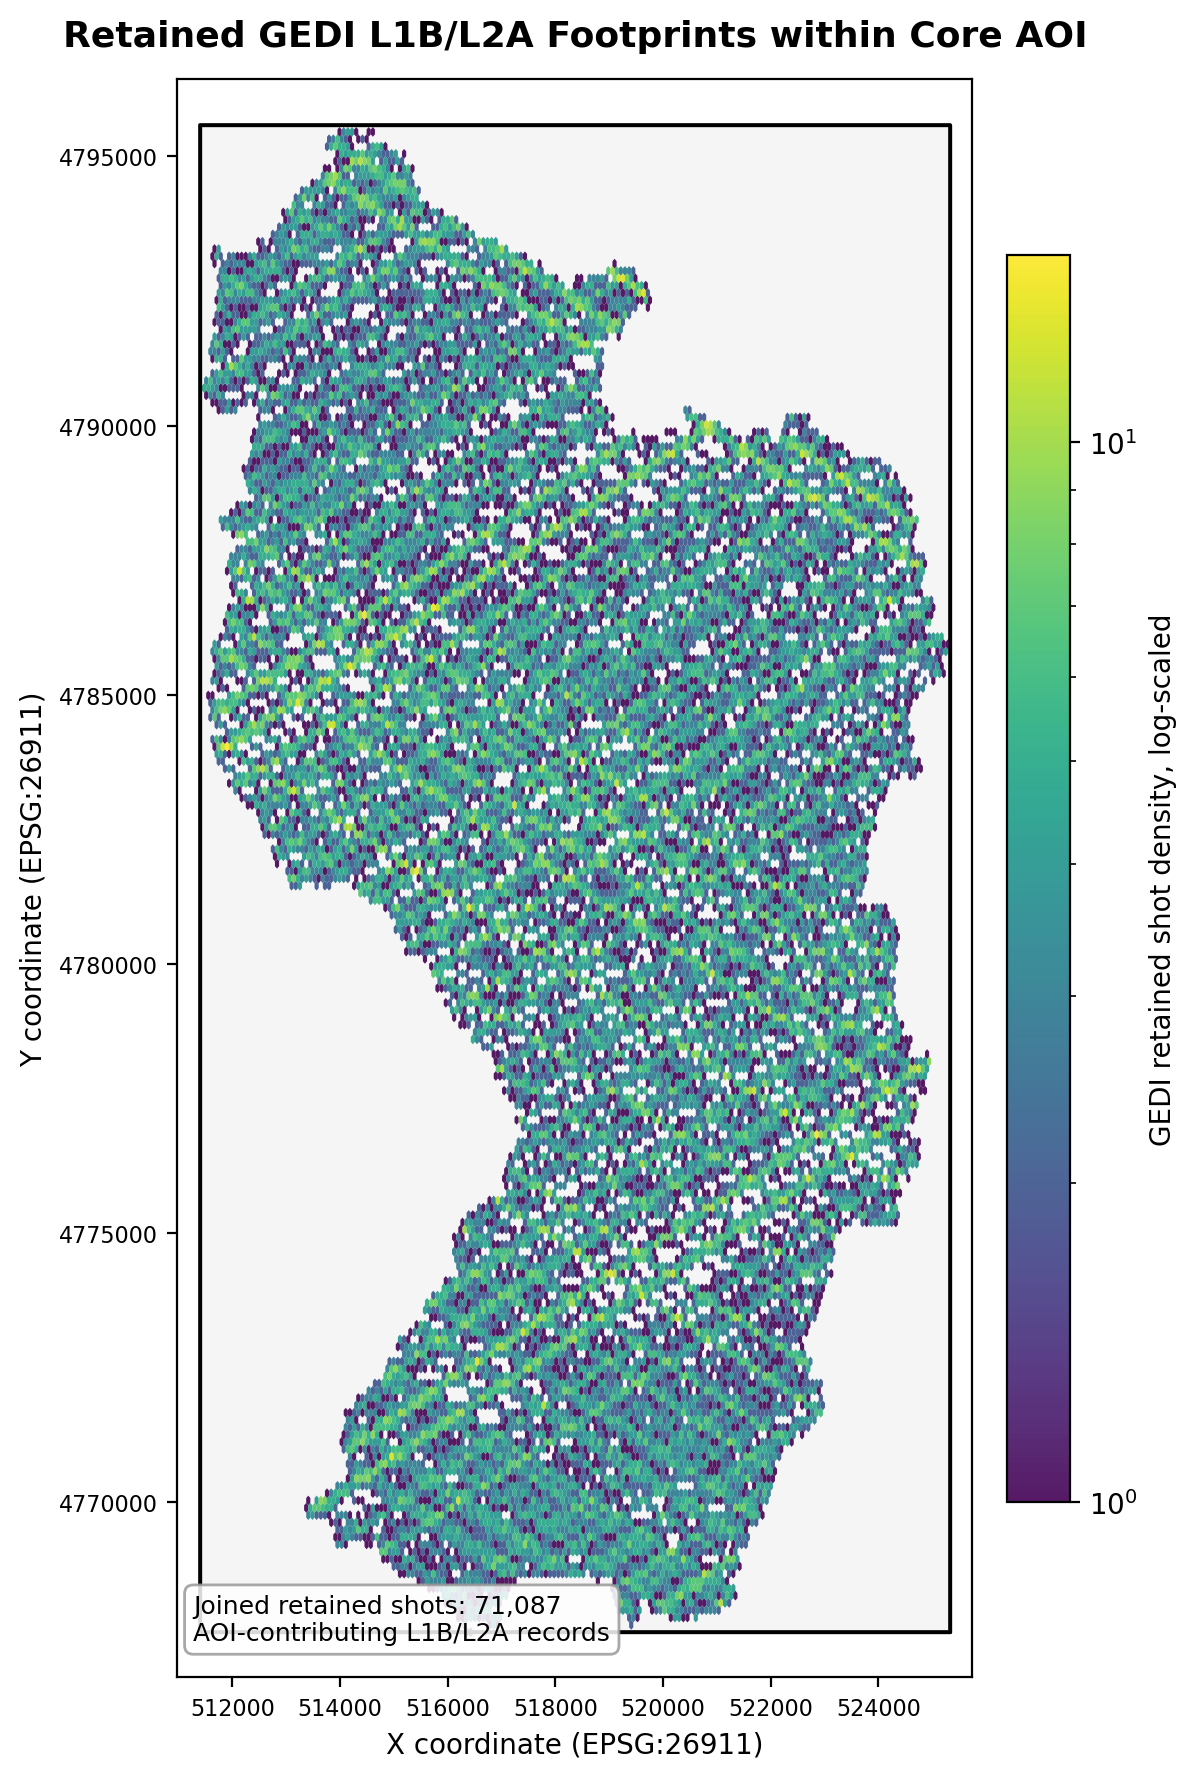

Wrote figure: A:\RCEW_DATA\Ancillary_Data\GEDI\NCA_template_bbox_L1B_L2A\outputs\gedi_retained_joined_shot_density_core_aoi.png


In [17]:
# ============================================================
# Clean GEDI retained-shot density plot over AOI
# Source: joined_core_gdf
# Requires: aoi_native, raster_crs, joined_core_gdf
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from pathlib import Path

# -----------------------------
# Settings
# -----------------------------
OUT_DIR = Path(r"A:\RCEW_DATA\Ancillary_Data\GEDI\NCA_template_bbox_L1B_L2A\outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

FIG_OUT = OUT_DIR / "gedi_retained_joined_shot_density_core_aoi.png"

# Use joined retained GEDI product
gedi_plot = joined_core_gdf.copy()

# Make sure CRS matches AOI
if gedi_plot.crs != aoi_native.crs:
    gedi_plot = gedi_plot.to_crs(aoi_native.crs)

# Optional: use only quality_flag == 1 for a second cleaner visual
# Comment this out if you want all retained joined shots.
# if "quality_flag" in gedi_plot.columns:
#     gedi_plot = gedi_plot[gedi_plot["quality_flag"] == 1].copy()

# Get x/y from geometry
x = gedi_plot.geometry.x.to_numpy()
y = gedi_plot.geometry.y.to_numpy()

# AOI bounds with padding
xmin, ymin, xmax, ymax = aoi_native.total_bounds
xpad = (xmax - xmin) * 0.03
ypad = (ymax - ymin) * 0.03

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(9, 9), dpi=200)

# AOI fill and boundary
aoi_native.plot(
    ax=ax,
    facecolor="0.96",
    edgecolor="0.15",
    linewidth=1.4,
    zorder=1
)

# Density plot using hexbin
hb = ax.hexbin(
    x,
    y,
    gridsize=180,
    extent=(xmin, xmax, ymin, ymax),
    mincnt=1,
    bins="log",
    linewidths=0,
    alpha=0.9,
    zorder=2
)

# AOI boundary again on top
aoi_native.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=1.2,
    zorder=3
)

# Colorbar
cb = fig.colorbar(hb, ax=ax, shrink=0.78, pad=0.02)
cb.set_label("GEDI retained shot density, log-scaled", fontsize=10)

# Axes and title
ax.set_title(
    "Retained GEDI L1B/L2A Footprints within Core AOI",
    fontsize=13,
    weight="bold",
    pad=12
)

ax.set_xlabel(f"X coordinate ({raster_crs})", fontsize=10)
ax.set_ylabel(f"Y coordinate ({raster_crs})", fontsize=10)

ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)

ax.set_aspect("equal")
ax.grid(False)

# Cleaner ticks
ax.ticklabel_format(style="plain", useOffset=False)
ax.tick_params(axis="both", labelsize=8)

# Annotation
txt = (
    f"Joined retained shots: {len(gedi_plot):,}\n"
    f"AOI-contributing L1B/L2A records"
)
ax.text(
    0.02,
    0.02,
    txt,
    transform=ax.transAxes,
    fontsize=9,
    va="bottom",
    ha="left",
    bbox=dict(facecolor="white", edgecolor="0.6", alpha=0.85, boxstyle="round,pad=0.35"),
    zorder=4
)

plt.tight_layout()
plt.savefig(FIG_OUT, dpi=300, bbox_inches="tight")
plt.show()

print(f"Wrote figure: {FIG_OUT}")

## 13. Quick map check


Text(169.5209722222222, 0.5, 'Y (EPSG:26911)')

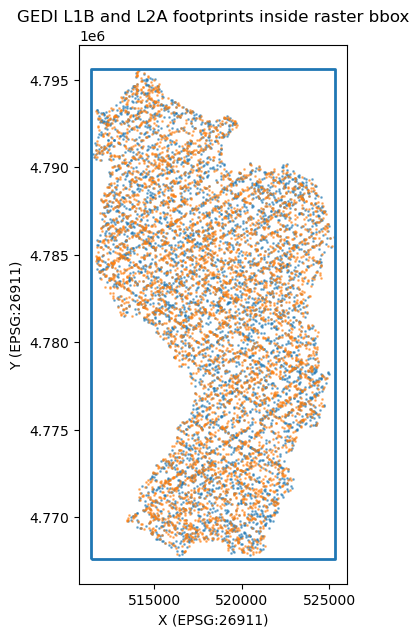

In [18]:
plot_l1b = l1b_native.sample(min(len(l1b_native), 5000), random_state=42) if len(l1b_native) else l1b_native
plot_l2a = l2a_native.sample(min(len(l2a_native), 5000), random_state=42) if len(l2a_native) else l2a_native

ax = aoi_native.boundary.plot(figsize=(7, 7), linewidth=2)
if len(plot_l1b):
    plot_l1b.plot(ax=ax, markersize=1, alpha=0.5)
if len(plot_l2a):
    plot_l2a.plot(ax=ax, markersize=1, alpha=0.5)
ax.set_title("GEDI L1B and L2A footprints inside raster bbox")
ax.set_xlabel(f"X ({raster_crs})")
ax.set_ylabel(f"Y ({raster_crs})")


## Notes for adapting this notebook

- `GEDI01_B` is the L1B geolocated waveform product. Use it when you need waveform-level information, receive-waveform sample indices, and waveform extraction.
- `GEDI02_A` is the L2A elevation and relative-height product. Use it when you need interpreted ground/canopy metrics such as `rh95`, `rh98`, `rh100`, `elev_lowestmode`, and quality flags.
- The spatial query is bounding-box based at CMR search time; exact footprint filtering is performed after reading the HDF5 files.
- For science use, inspect `quality_flag`, `degrade_flag`, `sensitivity`, beam type, slope/incidence geometry, and acquisition dates before final filtering.
- For dryland/low-stature systems, do not blindly drop ambiguous L2A returns without checking whether filtering preferentially removes the exact sparse/low-canopy cases you care about.
